------ Starting Optimized Lagrangian Relaxation ------
Iteration  |  Lower Bound  |  Upper Bound  |   Gap (%)
------------------------------------------------------
    1 |         3.0000 |         3.9000 |    23.077%
   11 |         3.0000 |         3.0241 |     0.796%
   21 |         3.0000 |         3.0045 |     0.149%
   31 |         3.0000 |         3.0007 |     0.025%
   41 |         3.0000 |         3.0001 |     0.004%
   51 |         3.0000 |         3.0000 |     0.001%
   61 |         3.0000 |         3.0000 |     0.000%
Converged achieved at iteration 62 by gap tolerance.
------------------------------------------------------
Solving exact MIS for comparison...
Final UB: 3.0000 | Exact: 3.0000 | Duality Gap: 0.000%


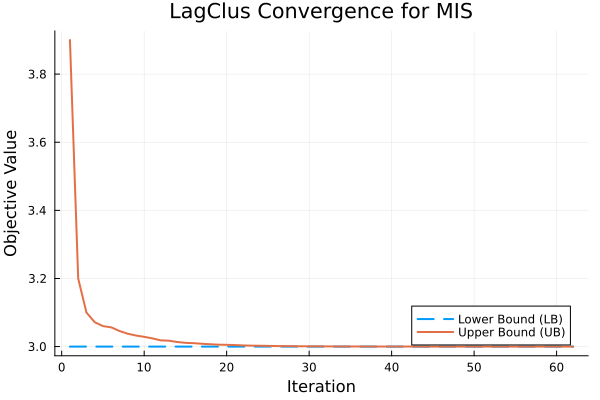

In [1]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 7 – Lagrangian relaxation
#  Section: 7.4 - Lagrangian relaxation for the Maximum Independent Set Problem
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP            # For mathematical programming
using HiGHS           # HiGHS solver
using Graphs          # Graphs package
using Karnak          # Graphs Visualization package
using Metis           # For graph partitioning
using LinearAlgebra   # For norm calculation
using Printf          # For formatted output
using Plots           # For plotting convergence

# Function to plot convergence of LB and UB
function plot_convergence(lb_history, ub_history)
    p = plot(1:length(lb_history), [lb_history ub_history],
        label=["Lower Bound (LB)" "Upper Bound (UB)"],
        xlabel="Iteration",
        ylabel="Objective Value",
        title="LagClus Convergence for MIS",
        linewidth=2,
        linestyle=[:dash :solid],  # Different line styles for each series
        legend=:bottomright)
    display(p)
end

# Function to solve MISP exactly
function solve_misp_exact(graph)
    n = Graphs.nv(graph)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[1:n], Bin)
    # Objective: Maximize sum of x[i]
    @objective(model, Max, sum(x[i] for i in 1:n))
    # Constraints: x[u] + x[v] <= 1 for each edge (u,v)
    for e in Graphs.edges(graph)
        u = Graphs.src(e)
        v = Graphs.dst(e)
        @constraint(model, x[u] + x[v] <= 1)
    end
    # Run the solver
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Function to partition graph using Metis
function metis_partition(graph, k)
    partition = Metis.partition(graph, k)
    clusters = [Int[] for _ in 1:k]
    for v in 1:Graphs.nv(graph)
        push!(clusters[partition[v]], v)
    end
    cut_edges = []
    for (e_id, e) in enumerate(Graphs.edges(graph))
        u = Graphs.src(e)
        v = Graphs.dst(e)
        if partition[u] != partition[v]
            push!(cut_edges, (u,v))
        end
    end
    return clusters, cut_edges
end

# Function to create a feasible solution from Lagrangian solution
function create_feasible_solution(graph, lag_solution)
    n = Graphs.nv(graph)
    feasible_solution = copy(lag_solution)
    # Greedily remove conflicts
    for u in 1:n
        if feasible_solution[u] == 1
            for v in Graphs.neighbors(graph, u)
                if feasible_solution[v] == 1
                    # Break tie by degree (drop node with higher degree)
                    if Graphs.degree(graph, u) ≥ Graphs.degree(graph, v)
                        feasible_solution[u] = 0
                    else
                        feasible_solution[v] = 0
                    end
                end
            end
        end
    end
    return feasible_solution
end

# Function to solve Lagrangian subproblem for a cluster
function solve_lagrangian_misp(graph, cluster, λ, solution)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Variables
    @variable(model, x[cluster], Bin)

    # Objective: Maximize sum of x[i]
    obj = sum(x[i] for i in cluster)
    
    # Add λ terms to objective and constraints
    for u in cluster
        for v in Graphs.neighbors(graph, u)
            if v in cluster
                if u < v
                    @constraint(model, x[u] + x[v] <= 1)
                end
            else
                if u < v
                    obj -= λ[(u,v)] * x[u]
                else
                    obj -= λ[(v,u)] * x[u]
                end
            end
        end
    end
    @objective(model, Max, obj)

    # Run the solver
    JuMP.optimize!(model)

    # Get the values of the decision variables
    for i in cluster
        solution[i] = JuMP.value(x[i])
    end

    return JuMP.objective_value(model)
end

# Main function to solve MISP using LagClus
function solve_lagclus_misp(graph; max_iterations = 2, k = 2, gap_tolerance = 0.0001)

    # Get Metis partition
    clusters, cut_edges = metis_partition(graph, k)

    # Initialize Lagrange multipliers for cut edges
    λ = Dict{Tuple{Int,Int}, Float64}()
    for (u,v) in cut_edges
        λ[(u,v)] = 0.1
    end

    # Initialize parameters
    LB = -Inf # Upper bound
    UB = Inf  # Lower bound
    LB_history = [] # Lower bound history
    UB_history = [] # Upper bound history
    θ = 0.8   # A factor to update multiplier (Held-Karp)
    
    # Counter logic for robust convergence
    # Halve θ if UB doesn't improve for 10 iterations
    no_improve_limit = 10
    no_improve_counter = 0

    println("------ Starting Optimized Lagrangian Relaxation ------")
    println("Iteration  |  Lower Bound  |  Upper Bound  |   Gap (%)")
    println("-"^54)

    best_feasible_solution = zeros(Graphs.nv(graph))

    for iteration in 1:max_iterations

        # Solve Lagrangian subproblems
        lag_objective = 0.0
        lag_solution = zeros(Graphs.nv(graph))
        for cluster in clusters
            lag_objective += solve_lagrangian_misp(graph, cluster, λ, lag_solution)
        end
        lag_objective += sum(λ[(u,v)] for (u,v) in cut_edges)

        # Update UB (Upper bound)
        if lag_objective < UB
            UB = lag_objective
            no_improve_counter = 0
        else
            no_improve_counter += 1
            # Held-Karp Rule: Reduce θ if progress stalls
            if no_improve_counter >= no_improve_limit
                θ *= 0.5
                no_improve_counter = 0
            end
        end
        UB = min(lag_objective, UB)

        # Create a feasible solution by greedy repair
        feasible_solution = create_feasible_solution(graph, lag_solution)
        feasible_objective = sum(feasible_solution)

        if feasible_objective > LB
            LB = feasible_objective    
            best_feasible_solution = copy(feasible_solution)
        end

        # Store history
        push!(LB_history, LB)
        push!(UB_history, UB)

        # Compute gap
        gap = (UB - LB) / UB

        # Print iteration results
        if iteration % 10 == 1
            @printf("%5d | %14.4f | %14.4f | %9.3f%%\n", 
                    iteration, LB, UB, gap * 100)
        end

        # Check convergence
        if gap < gap_tolerance
            println("Converged achieved at iteration $iteration by gap tolerance.")
            break
        end
        
        # Update Lagrange multipliers
        g = []
        for (u,v) in cut_edges
            grad = lag_solution[u] + lag_solution[v] - 1
            λ[(u,v)] = max(0.0, λ[(u,v)] + θ * grad)
            push!(g, grad)
        end
        g = norm(g)

        # Check for small gradient norm
        if g < 1e-6
            println("Gradient norm small: ", g)
            break
        end
        
        # Adaptive step-size update (Held-Karp)
        θ = 0.2 * ((UB - LB) / (g + 1e-8))
    end

    # Final summary and Exact solve for comparison
    exact_objective = solve_misp_exact(graph)
    println("-"^54)
    println("Solving exact MIS for comparison...")
    @printf("Final UB: %.4f | Exact: %.4f | Duality Gap: %.3f%%\n", 
            UB, exact_objective, 100 * abs(exact_objective- UB)/exact_objective)

    # Plot convergence
    plot_convergence(LB_history, UB_history)
end

# Create graph
edges = [(1,2), (1,7), (1,8), (2,3), 
         (2,8), (3,5), (3,6), (3,7), 
         (4,5), (4,7), (5,6), (7,8)]

graph = Graph(8)
for (u,v) in edges
    add_edge!(graph, u, v)
end

using Random
Random.seed!(1)

# Example usage
solve_lagclus_misp(graph, max_iterations = 200, k=2, gap_tolerance = 1e-6)